In [1]:
!pip install scikit-learn --quiet

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Load engineered features
df = pd.read_csv('fraud_features_ready.csv')

# Split features and target
X = df.drop('isFraud', axis = 1)
y = df['isFraud']

# Split train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print(f"Training set: {len(X_train)} transactions")
print(f"Test set: {len(X_test)} transactions")
print(f"\nTraining fraud rate: {y_train.mean()*100:.3f}%")

# Scale features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled!")

Training set: 2216327 transactions
Test set: 554082 transactions

Training fraud rate: 0.296%

Features scaled!


# Class Imbalance

In [5]:
!pip install imbalanced-learn --quiet

In [6]:
from imblearn.over_sampling import SMOTE

# Fraud is 0.13% - very imbalanced!
# SMOTE creates synthetic fraud examples

print("Balancing dataset with SMOTE...")
smote = SMOTE(random_state=42, sampling_strategy=0.3)  # Make frauds 30% of dataset
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set: {len(X_train)} transactions")
print(f"Balanced training set: {len(X_train_balanced)} transactions")
print(f"New fraud rate: {y_train_balanced.mean()*100:.1f}%")

Balancing dataset with SMOTE...
Original training set: 2216327 transactions
Balanced training set: 2872684 transactions
New fraud rate: 23.1%


# Train Models

In [11]:
!pip install xgboost --quiet

In [12]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import time

# Model 1: Random Forest
print("\n" + "="*50)
print("Training Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_balanced, y_train_balanced)

print(f"Training time: {time.time()-start:.2f} seconds")

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

# Model 2: XGBoost
print("\n" + "="*50)
print("Training XGBoost...")
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc'
)
xgb_model.fit(X_train_balanced, y_train_balanced)

print(f"Training time: {time.time()-start:.2f} seconds")

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("\nXGBoost Results:")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")


Training Random Forest...
Training time: 269.02 seconds

Random Forest Results:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552439
       Fraud       0.91      1.00      0.95      1643

    accuracy                           1.00    554082
   macro avg       0.96      1.00      0.98    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC Score: 0.9991

Training XGBoost...
Training time: 18.90 seconds

XGBoost Results:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552439
       Fraud       0.48      0.99      0.65      1643

    accuracy                           1.00    554082
   macro avg       0.74      0.99      0.82    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC Score: 0.9994


# Finetuning XGBOOST

In [14]:
from sklearn.model_selection import RandomizedSearchCV

smote = SMOTE(random_state=42, sampling_strategy=0.3)  # Make frauds 30% of dataset
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [15]:
# Calculate scale_pos_weight
# (Normal / Fraud)
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',   # faster & scalable
    use_label_encoder=False,
    scale_pos_weight=scale   # handles imbalance
)

param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'n_estimators': [200, 400, 600]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',      # Balanced scoring for both classes
    cv=3,
    verbose=2,
    n_jobs=-1
)

search.fit(X_train_bal, y_train_bal)
best_xgb = search.best_estimator_

y_pred = best_xgb.predict(X_test)
print("Best Parameters:", search.best_params_)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]))

Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [22:09:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.98      1.00      0.99      1643

    accuracy                           1.00    554082
   macro avg       0.99      1.00      0.99    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC: 0.9991464553641208


# Feature Importance Analysis

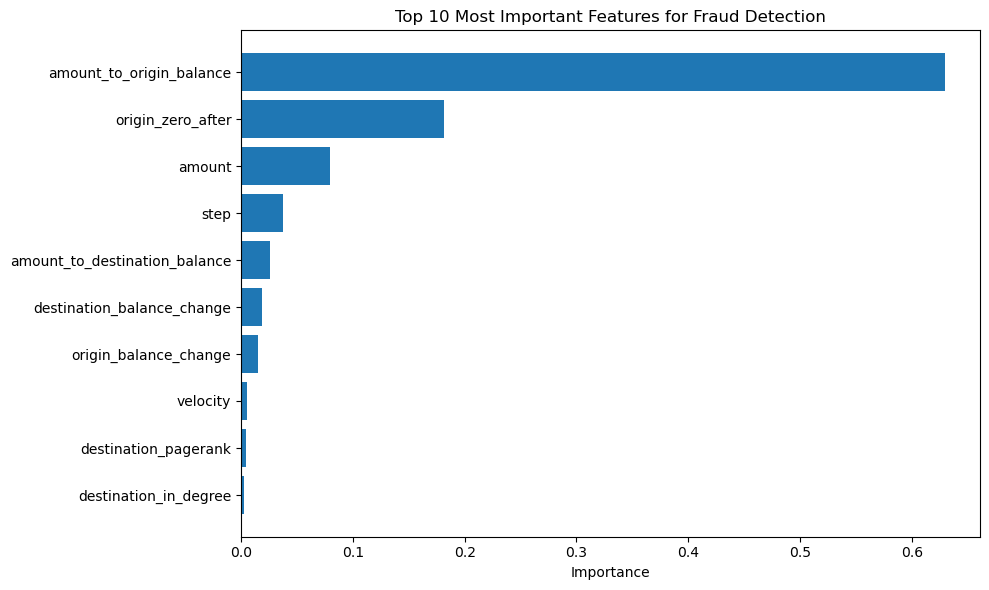


Top 10 Features:
                          feature  importance
8        amount_to_origin_balance    0.629446
6               origin_zero_after    0.181165
1                          amount    0.079246
0                            step    0.037650
9   amount_to_destination_balance    0.025641
3      destination_balance_change    0.018595
2           origin_balance_change    0.015031
14                       velocity    0.005248
13           destination_pagerank    0.004664
11          destination_in_degree    0.002543


In [16]:
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], 
         feature_importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features for Fraud Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10))

# Saving the model

In [17]:
import joblib

# Save models
joblib.dump(best_xgb, 'xgb_fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Models saved!")
print("- xgb_fraud_model.pkl")
print("- scaler.pkl")

Models saved!
- xgb_fraud_model.pkl
- scaler.pkl
